In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
data_matrix = pd.read_csv('data/input/internship_data_matrix.csv', index_col=0)
feature_metadata = pd.read_csv('data/input/internship_feature_metadata.csv', index_col=0)
acquisition_list = pd.read_csv('data/input/intership_acquisition_list.csv', index_col=0)
exogenous_standards = pd.read_csv('data/input/exogenous_standards.csv')

In [3]:
# Filter to only batch 1
batch1_samples = acquisition_list[acquisition_list['batch'] == 1].index
data_matrix = data_matrix.loc[batch1_samples]
acquisition_list = acquisition_list.loc[batch1_samples]

Before doing any processing, lets take a look at our data and evaluate it

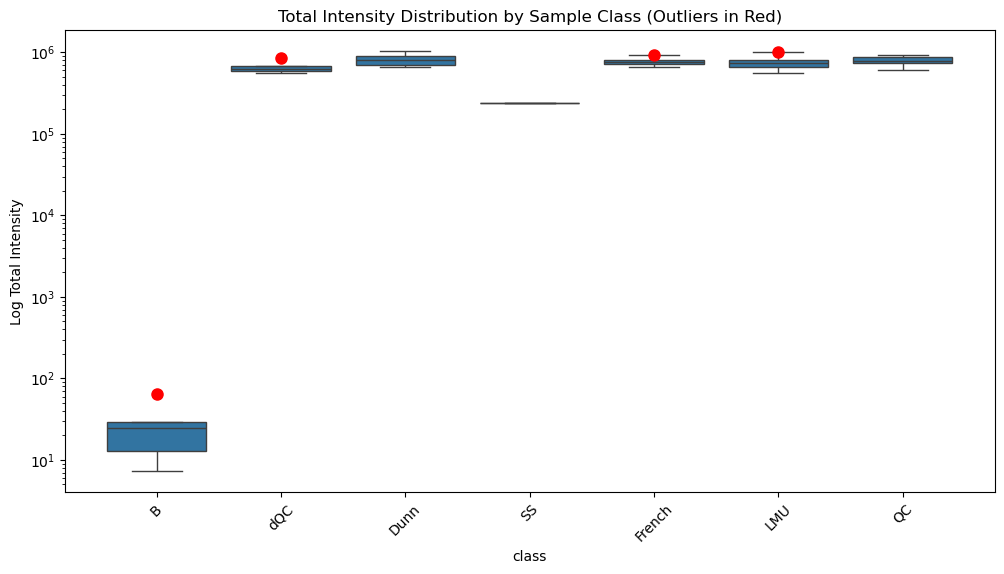

Identified class-specific outlier samples: ['20241106-297-Blank3', '20241106-297-Diluted-QC5', '20241106-297-French-4', '20241106-297-LMU-13']


In [4]:
def evaluate_sample_quality(data_matrix, acquisition_list):
    # Calculate total intensity per sample
    sample_totals = data_matrix.sum(axis=1)
    sample_totals.name = 'total_intensity' 
    sample_stats = pd.concat([sample_totals, acquisition_list['class']], axis=1)
    
    # Calculate median and MAD for each class
    class_stats = sample_stats.groupby('class')['total_intensity'].agg(
        ['median', lambda x: stats.median_abs_deviation(x)]
    )
    class_stats.columns = ['class_median', 'class_mad']
    sample_stats = sample_stats.merge(class_stats, left_on='class', right_index=True)
    
    # Identify outliers (we define outliers as being more than 3 MAD from class median)
    sample_stats['is_outlier'] = abs(sample_stats['total_intensity'] - sample_stats['class_median']) >  3 * sample_stats['class_mad']

    plt.figure(figsize=(12, 6))
    ax = sns.boxplot(x='class', y='total_intensity', data=sample_stats)
    outliers = sample_stats[sample_stats['is_outlier']]
    for i, point in outliers.iterrows():
        ax.plot(point['class'], point['total_intensity'], 'ro', markersize=8)
    plt.yscale('log')
    plt.title('Total Intensity Distribution by Sample Class (Outliers in Red)')
    plt.ylabel('Log Total Intensity')
    plt.xticks(rotation=45)
    plt.show()
    
    return outliers.index.tolist()

sample_outliers = evaluate_sample_quality(data_matrix, acquisition_list)
print(f"Identified class-specific outlier samples: {sample_outliers}")

Now lets filter our data.

We start by filtering our features

In [5]:
DETECTION_THRESHOLD = 500

# Define function to calculate CV
def calculate_cv(series):
    mean = series[series > 0].mean()
    std = series[series > 0].std()
    return (std / mean) if mean > 0 else np.inf

# Filter by mass (> 500 m/z)
valid_mass = feature_metadata['mz'] > 500
features_to_keep = valid_mass

# Exclude features with detection rate < 70% within the classes
for cls in acquisition_list['class'].unique():
    if cls == 'B' or cls == 'SS':
        continue
    samples = acquisition_list[acquisition_list['class'] == cls].index
    detection_rate_cls = (data_matrix.loc[samples] > DETECTION_THRESHOLD).mean()
    features_to_keep &= (detection_rate_cls >= 0.7)

# Calculate CV in QCs (<30% variability)
qc_samples = acquisition_list[acquisition_list['class'].isin(['QC', 'dQC'])].index
cv_qc = data_matrix.loc[qc_samples].apply(calculate_cv, axis=0)
features_to_keep &= (cv_qc < 0.3)

# Exclude features with detection rate > 30% in blanks
blank_samples = acquisition_list[acquisition_list['class'] == 'B'].index
detection_rate_blank = (data_matrix.loc[blank_samples] > DETECTION_THRESHOLD).mean()
features_to_keep &= (detection_rate_blank <= 0.3)

# Could also exclude features with unstable retention time, or feature that are likely noise

# Apply all filters
filtered_features = feature_metadata.index[features_to_keep]
filtered_data = data_matrix[filtered_features]
filtered_metadata = feature_metadata.loc[filtered_features]

print(f"Original features: {data_matrix.shape[1]}, Filtered features: {filtered_data.shape[1]}")

Original features: 252, Filtered features: 135


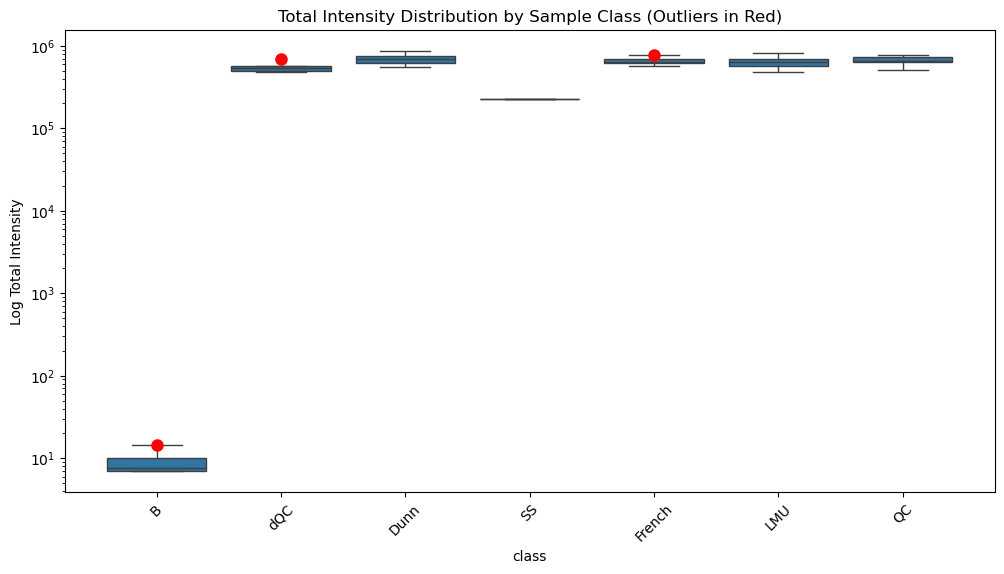

Identified class-specific outlier samples: ['20241106-297-Blank4', '20241106-297-Blank6', '20241106-297-Diluted-QC5', '20241106-297-French-21']


In [6]:
sample_outliers = evaluate_sample_quality(filtered_data, acquisition_list)
print(f"Identified class-specific outlier samples: {sample_outliers}")

We see the same nmber of outliers, but now 2 of them are blanks. Now we can filter on samples:

In [7]:
# Check for contaminated samples by comparing intensities of features with those of blanks samples (intensities just above blanks are likely noise)

blank_mean = filtered_data.loc[blank_samples].mean(axis=0)
non_blank_samples = acquisition_list[acquisition_list['class'] != 'B'].index
sample_contamination = filtered_data.loc[non_blank_samples].div(blank_mean, axis=1)
sample_contamination_score = sample_contamination.mean(axis=1)

contamination_threshold = 5
contaminated_samples = sample_contamination_score[sample_contamination_score < contamination_threshold].index
refiltered_data = filtered_data.drop(contaminated_samples, axis=0)

print(f"Original samples: {filtered_data.shape[0]}, Filtered samples: {refiltered_data.shape[0]}")

Original samples: 102, Filtered samples: 102


Second filtering did not eiliminate any sample in this case. Changing contamination_threshold might affect results.

In [8]:
# Save processed data
refiltered_data.to_csv('data/processed/filtered_data.csv')
filtered_metadata.to_csv('data/processed/filtered_metadata.csv')
acquisition_list.to_csv('data/processed/filtered_acquisition_list.csv')